# Multi-Model Comparison Using the 2009 Quantitative Single-Neuron Modeling Competition Dataset

This notebook is a validation and extension of Figure 3 from the [Kobayashi et al., 2009](https://nih.gov) paper. In this section of the results, the authors utilise the [2009 Quantitative Single-Neuron Modeling Competition (QSNMC) dataset](https://github.com/InPhyT/Quantitative_Single_Neuron_Modeling_Competition_2009/tree/main) of cortical neurons, feed these neuronal models biological currents, and compare the biological output against the computational output. The comparison is performed using a coincidence-factor equation detailed below.

### Assessment of Predictive Performance

The performance of the spike time prediction is assessed with a coefficient measuring the degree of coincidence of a model spike train with a real spike train. Among various methods for measuring the similarity between two spike trains, we adopted here the coincidence factor $\Gamma$ (Jolivet et al., 2004, 2006, 2008a; Kobayashi and Shinomoto, 2007), defined by:

$$ \Gamma = \frac{N_{\text{coinc}} - \langle N_{\text{coinc}} \rangle}{\frac{1}{2}(N_{\text{data}} + N_{\text{model}})} \times \frac{1}{1 - 2\nu\Delta} \quad (5) $$

Where:
* $N_{\text{data}}$ and $N_{\text{model}}$ represent the numbers of spikes in the experimental data and the computational model, respectively.
* $N_{\text{coinc}}$ is the number of coincident spikes occurring within an allowable temporal window $\Delta$.
* $\langle N_{\text{coinc}} \rangle = 2\nu\Delta N_{\text{data}}$ is the expected number of coincidences between the data and random Poisson spikes of the given firing rate $\nu$. 

By subtracting $\langle N_{\text{coinc}} \rangle$, the baseline coefficient evaluates to approximately $0$ for mutually independent spike trains. The entire coefficient is normalized by dividing by $1 - 2\nu\Delta$ so that $\Gamma = 1$ if all model spikes successfully coincide within the window $\Delta$. In this study, $\Delta$ is chosen to be $2\text{ ms}$.

Each neuron model was tailored to every biological neuron using sample current–voltage data by maximizing the coincidence score $\Gamma$. The model was then tested with a novel current injection dataset to evaluate its predictive capabilities. The final predictive performance was assessed based on the normalized coincidence scores ($\Gamma'$), relative to the experimental trial-to-trial variation, defined by:

$$ \Gamma' = \frac{\Gamma_{\text{model-experiment}}}{\Gamma_{\text{experiment-experiment}}} \quad (6) $$

I've copied in Figure 3.0 from [Kobayashi et al., 2009] below. 


<img src="../images/multi_model_comparision.png" width="1050" height="600">

In [11]:
from pathlib import Path
from itertools import combinations
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nest
import pynestml
from scipy.optimize import differential_evolution
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils

SEED = 12345
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)

print("NEST version:", nest.__version__)
print("NumPy version:", np.__version__)

NEST version: 3.9.0-post0.dev14
NumPy version: 2.5.1


# Spike extraction and coincidence helper functions 

The following functions use one-to-one matching, preserving negative scores and uses the model rate for chance correction 

In [12]:
def extract_biological_spikes(voltage_trace, dt_ms=0.1, threshold_mv=-10.0):
    """Return upward threshold-crossing times in milliseconds."""
    v = np.asarray(voltage_trace, dtype=float).reshape(-1)

    if len(v) < 2:
        return np.array([], dtype=float)

    crossings = np.flatnonzero(
        (v[:-1] < threshold_mv) &
        (v[1:] >= threshold_mv)
    )

    return (crossings + 1) * dt_ms


def count_coincident_spikes(data_spikes, model_spikes, delta_ms=2.0):
    """Count one-to-one spike coincidences within ±delta_ms."""
    data_spikes = np.sort(np.asarray(data_spikes, dtype=float))
    model_spikes = np.sort(np.asarray(model_spikes, dtype=float))

    i = 0
    j = 0
    n_coinc = 0

    while i < len(data_spikes) and j < len(model_spikes):
        difference = model_spikes[j] - data_spikes[i]

        if abs(difference) <= delta_ms:
            n_coinc += 1
            i += 1
            j += 1
        elif difference < -delta_ms:
            j += 1
        else:
            i += 1

    return n_coinc


def calculate_coincidence_factor(
    model_spikes,
    data_spikes,
    duration_ms,
    delta_ms=2.0,
):
    """Calculate the chance-corrected coincidence factor Gamma."""
    model_spikes = np.asarray(model_spikes, dtype=float)
    data_spikes = np.asarray(data_spikes, dtype=float)

    n_model = len(model_spikes)
    n_data = len(data_spikes)

    if duration_ms <= 0:
        raise ValueError("duration_ms must be positive.")

    if n_model + n_data == 0:
        return np.nan

    duration_sec = duration_ms / 1000.0
    delta_sec = delta_ms / 1000.0

    # Rate of the model/comparison train.
    nu = n_model / duration_sec

    expected_coincidences = 2.0 * nu * delta_sec * n_data
    chance_normalisation = 1.0 - 2.0 * nu * delta_sec

    if chance_normalisation <= 0:
        return np.nan

    n_coinc = count_coincident_spikes(
        data_spikes=data_spikes,
        model_spikes=model_spikes,
        delta_ms=delta_ms,
    )

    gamma = (
        (n_coinc - expected_coincidences)
        / (0.5 * (n_data + n_model))
        / chance_normalisation
    )

    return float(gamma)


def calculate_experimental_reliability(
    voltage_repetitions,
    dt_ms=0.1,
    threshold_mv=-10.0,
    delta_ms=2.0,
):
    """
    Mean pairwise experiment–experiment Gamma over repeated trials.

    Both directional scores are averaged because the chance correction
    depends on which train is treated as the comparison train.
    """
    voltage_repetitions = np.asarray(voltage_repetitions, dtype=float)

    if voltage_repetitions.ndim != 2:
        raise ValueError("Expected samples × repetitions.")

    duration_ms = voltage_repetitions.shape[0] * dt_ms

    spike_trains = [
        extract_biological_spikes(
            voltage_repetitions[:, repetition],
            dt_ms=dt_ms,
            threshold_mv=threshold_mv,
        )
        for repetition in range(voltage_repetitions.shape[1])
    ]

    pairwise_scores = []

    for first, second in combinations(range(len(spike_trains)), 2):
        forward = calculate_coincidence_factor(
            model_spikes=spike_trains[second],
            data_spikes=spike_trains[first],
            duration_ms=duration_ms,
            delta_ms=delta_ms,
        )

        reverse = calculate_coincidence_factor(
            model_spikes=spike_trains[first],
            data_spikes=spike_trains[second],
            duration_ms=duration_ms,
            delta_ms=delta_ms,
        )

        pairwise_scores.append(np.nanmean([forward, reverse]))

    return {
        "reliability": float(np.nanmean(pairwise_scores)),
        "pairwise_scores": np.asarray(pairwise_scores),
        "spike_trains": spike_trains,
    }

### Loading in the 2009 challengeA dataset 

The current file contains 60 s of input. The voltage file contains only the first 39 s, with each column representing a repeated biological response to the same injected current.
- Training set is first 39 s
- Test set is last 21 seconds

In [13]:
# Load data
CURRENT_PATH = r"data_challengeA/current.csv"
VOLTAGE_PATH = r"data_challengeA/voltage_allrep.csv"

raw_current = pd.read_csv(CURRENT_PATH,header=None,names=["Current_pA"])
raw_voltage = pd.read_csv(VOLTAGE_PATH, header=None, sep=r"\s+")

current_pA = raw_current["Current_pA"].to_numpy(dtype=float)
voltage_mv = raw_voltage.to_numpy(dtype=float)

DT_MS = 0.1
DT_S = DT_MS / 1000.0

current_time_s = np.arange(len(current_pA)) * DT_S
voltage_time_s = np.arange(len(voltage_mv)) * DT_S

print(f"Current shape: {current_pA.shape}")
print(f"Voltage shape: {voltage_mv.shape}")
print(f"Biological repetitions: {voltage_mv.shape[1]}")
print(f"Current duration: {len(current_pA) * DT_S:.1f} s")
print(f"Voltage duration: {len(voltage_mv) * DT_S:.1f} s")

if len(voltage_mv) > len(current_pA):
    raise ValueError("Voltage recording is longer than the supplied current.")

Current shape: (600001,)
Voltage shape: (390000, 13)
Biological repetitions: 13
Current duration: 60.0 s
Voltage duration: 39.0 s


# Inspecting raw dataset segment 

Ensuring the injected current elicits a voltage response 

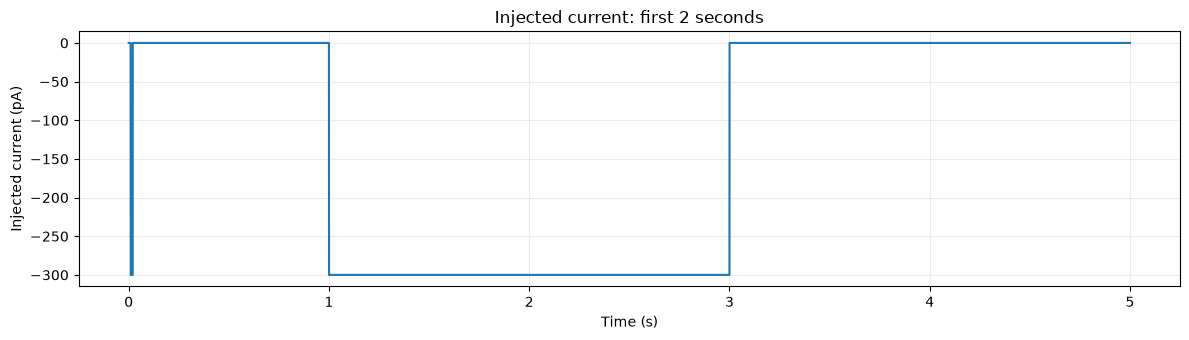

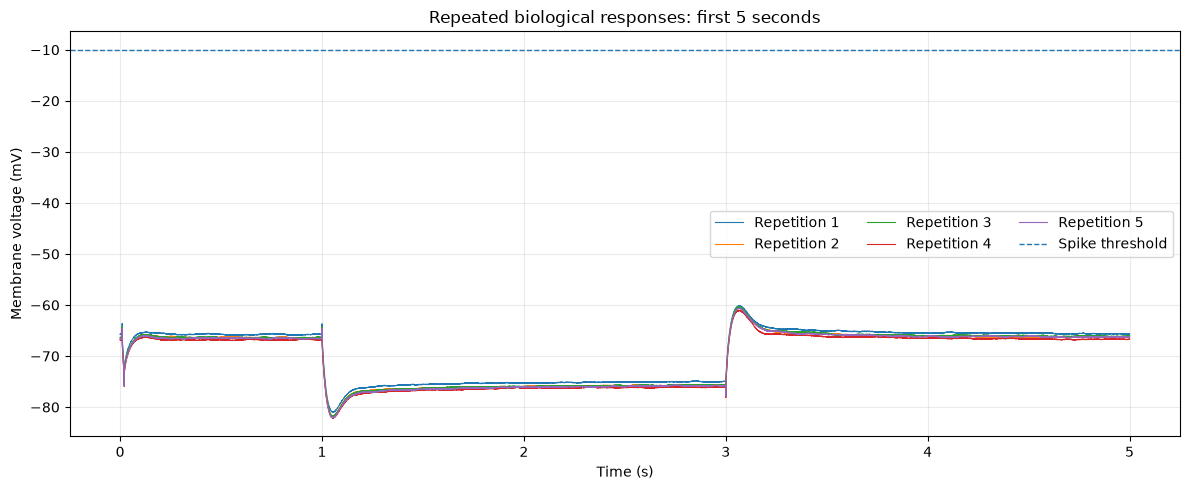

In [15]:
preview_start_s = 0.0
preview_end_s = 5.0

preview_slice = slice(
    int(preview_start_s / DT_S),
    int(preview_end_s / DT_S),
)

plt.figure(figsize=(12, 3.5))
plt.plot(
    current_time_s[preview_slice],
    current_pA[preview_slice],
)
plt.xlabel("Time (s)")
plt.ylabel("Injected current (pA)")
plt.title("Injected current: first 2 seconds")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for repetition in range(min(5, voltage_mv.shape[1])):
    plt.plot(
        voltage_time_s[preview_slice],
        voltage_mv[preview_slice, repetition],
        linewidth=0.8,
        label=f"Repetition {repetition + 1}",
    )

plt.axhline(-10.0, linestyle="--", linewidth=1, label="Spike threshold")
plt.xlabel("Time (s)")
plt.ylabel("Membrane voltage (mV)")
plt.title("Repeated biological responses: first 5 seconds")
plt.legend(ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Inspecting raw dataset whole  

Ensuring the github readme's are correct and there's a definite training set at 0-39 seconds. 

In [ ]:
 "# plotting injected currents across training and testing datasets \n",
    "plt.figure(figsize=(12,4))\n",
    "plt.plot(\n",
    "    t_train,\n",
    "    I_train,\n",
    "    label=\"Training current\",\n",
    "    color=\"tab:blue\"\n",
    ")\n",
    "\n",
    "plt.plot(\n",
    "    t_test,\n",
    "    I_test,\n",
    "    label=\"Testing current\",\n",
    "    color=\"tab:orange\"\n",
    ")\n",
    "\n",
    "plt.axvline(\n",
    "    train_duration,\n",
    "    color=\"black\",\n",
    "    linestyle=\"--\",\n",
    "    label=\"Train/Test split\"\n",
    ")\n",
    "\n",
    "plt.xlabel(\"Time (s)\")\n",
    "plt.ylabel(\"Injected current (pA)\")\n",
    "plt.title(\"Injected current waveform\")\n",
    "plt.grid(True)\n",
    "plt.legend()\n",
    "plt.tight_layout()\n",
    "plt.show()\n",
    "\n",
    "# plotting voltage response (avg across 13 channels) \n",
    "plt.figure(figsize=(12,4))\n",
    "plt.plot(\n",
    "    t_train,\n",
    "    V_train,\n",
    "    color=\"tab:red\",\n",
    "    label=\"Membrane voltage\"\n",
    ")\n",
    "\n",
    "plt.xlabel(\"Time (s)\")\n",
    "plt.ylabel(\"Membrane voltage (mV)\")\n",
    "plt.title(\"Training voltage response\")\n",
    "plt.grid(True)\n",
    "plt.legend()\n",
    "plt.tight_layout()\n",
    "plt.show()\n",
    "\n",
    "\n",
    "# combning both plots above together, overlaying the input currents and voltage responses for training \n",
    "# no injected current df for testing set. \n",
    "fig, ax1 = plt.subplots(figsize=(12,5))\n",
    "ax1.plot(\n",
    "    t_train,\n",
    "    I_train,\n",
    "    color=\"tab:blue\",\n",
    "    label=\"Training current\"\n",
    ")\n",
    "\n",
    "ax1.plot(\n",
    "    t_test,\n",
    "    I_test,\n",
    "    color=\"tab:orange\",\n",
    "    label=\"Testing current\"\n",
    ")\n",
    "\n",
    "ax1.set_xlabel(\"Time (s)\")\n",
    "ax1.set_ylabel(\"Injected current (pA)\")\n",
    "ax1.axvline(\n",
    "    train_duration,\n",
    "    color=\"black\",\n",
    "    linestyle=\"--\"\n",
    ")\n",
    "\n",
    "# Voltage\n",
    "ax2 = ax1.twinx()\n",
    "ax2.plot(\n",
    "    t_train,\n",
    "    V_train,\n",
    "    color=\"tab:red\",\n",
    "    linewidth=1,\n",
    "    label=\"Training voltage\"\n",
    ")\n",
    "\n",
    "ax2.set_ylabel(\"Membrane voltage (mV)\")\n",
    "\n",
    "# Combined legend\n",
    "lines1, labels1 = ax1.get_legend_handles_labels()\n",
    "lines2, labels2 = ax2.get_legend_handles_labels()\n",
    "\n",
    "ax1.legend(\n",
    "    lines1 + lines2,\n",
    "    labels1 + labels2,\n",
    "    loc=\"upper right\"\n",
    ")\n",
    "fig.tight_layout()\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "mar

# Fitting, validation and blind-test datasets

The dataset with biological voltage will be split by the following:
- Fitting: 0–25 s
- Validation: 25–39 s
- Blind challenge current: 39–60 s

This validation split prevents information leakage. The 21 s blind current has no local voltage target and is therefore not used to calculate a score.

In [16]:
FIT_START_S = 0.0
FIT_END_S = 25.0

VALIDATION_START_S = 25.0
VALIDATION_END_S = 39.0

BLIND_START_S = 39.0
BLIND_END_S = min(60.0, len(current_pA) * DT_S)


def seconds_to_slice(start_s, end_s, dt_s=DT_S):
    start_index = int(round(start_s / dt_s))
    end_index = int(round(end_s / dt_s))
    return slice(start_index, end_index)


fit_slice = seconds_to_slice(FIT_START_S, FIT_END_S)
validation_slice = seconds_to_slice(
    VALIDATION_START_S,
    VALIDATION_END_S,
)
blind_slice = seconds_to_slice(BLIND_START_S, BLIND_END_S)

I_fit = current_pA[fit_slice]
V_fit = voltage_mv[fit_slice, :]

I_validation = current_pA[validation_slice]
V_validation = voltage_mv[validation_slice, :]

I_blind = current_pA[blind_slice]

print("Fitting")
print(f"Current samples: {len(I_fit):,}")
print(f"Voltage shape: {V_fit.shape}")
print(f"Duration: {len(I_fit) * DT_S:.1f} s")

print("\nValidation")
print(f"Current samples: {len(I_validation):,}")
print(f"Voltage shape: {V_validation.shape}")
print(f"Duration: {len(I_validation) * DT_S:.1f} s")

print("\nBlind challenge current")
print(f"Current samples: {len(I_blind):,}")
print(f"Duration: {len(I_blind) * DT_S:.1f} s")

assert len(I_fit) == len(V_fit)
assert len(I_validation) == len(V_validation)

Fitting
Current samples: 250,000
Voltage shape: (250000, 13)
Duration: 25.0 s

Validation
Current samples: 140,000
Voltage shape: (140000, 13)
Duration: 14.0 s

Blind challenge current
Current samples: 210,000
Duration: 21.0 s


# Detect biological spikes and check the detector functions

The detector is applied separately to every repetition (neuron). In this cell we will analyse the firing rates and produce overlays to check to whether the selected threshold captures one event per action potential.

,repetition,fit_spikes,fit_rate_hz,validation_spikes,validation_rate_hz
0,1,161,6.44,176,12.571
1,2,175,7.00,147,10.500
2,3,173,6.92,136,9.714
3,4,178,7.12,172,12.286
4,5,206,8.24,200,14.286
5,6,188,7.52,153,10.929
6,7,166,6.64,155,11.071
7,8,119,4.76,126,9.000
8,9,94,3.76,77,5.500
9,10,54,2.16,53,3.786


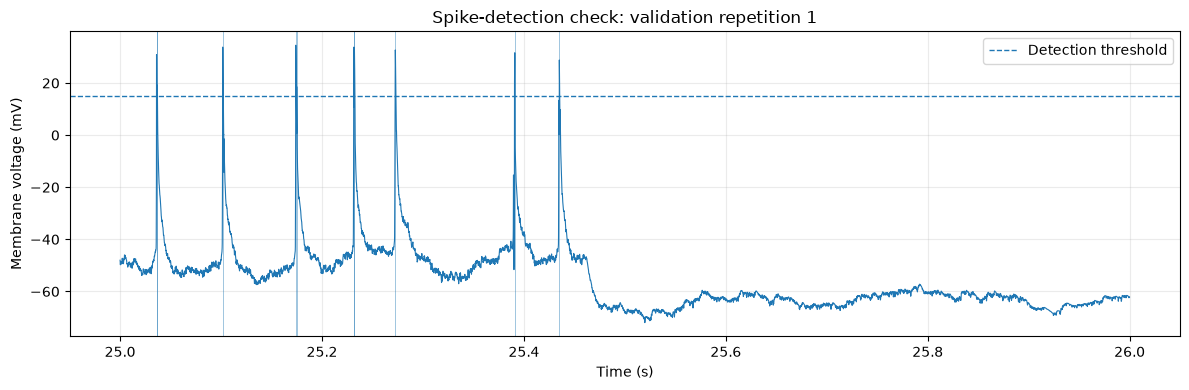

In [18]:
BIOLOGICAL_THRESHOLD_MV = 15.0
DELTA_MS = 2.0 # specified by the paper, as this is the sliding delta range 

fit_biological_spikes = [
    extract_biological_spikes(
        V_fit[:, repetition],
        dt_ms=DT_MS,
        threshold_mv=BIOLOGICAL_THRESHOLD_MV,
    )
    for repetition in range(V_fit.shape[1])
]

validation_biological_spikes = [
    extract_biological_spikes(
        V_validation[:, repetition],
        dt_ms=DT_MS,
        threshold_mv=BIOLOGICAL_THRESHOLD_MV,
    )
    for repetition in range(V_validation.shape[1])
]

fit_duration_s = len(I_fit) * DT_S
validation_duration_s = len(I_validation) * DT_S

# spiking summary acorss the fit/validation df 
spike_summary = pd.DataFrame({
    "repetition": np.arange(1, V_fit.shape[1] + 1), # across the 13 iterations 
    "fit_spikes": [len(s) for s in fit_biological_spikes],
    "fit_rate_hz": [len(s) / fit_duration_s for s in fit_biological_spikes],
    "validation_spikes": [len(s) for s in validation_biological_spikes],
    "validation_rate_hz": [
        len(s) / validation_duration_s
        for s in validation_biological_spikes
    ],
})

display(spike_summary.round(3))

# sample data to check threshold 
check_start_s = 25.0
check_end_s = 26.0
check_slice = seconds_to_slice(check_start_s, check_end_s) 

check_voltage = voltage_mv[check_slice, 0]
check_time_s = voltage_time_s[check_slice]
check_spikes_ms = extract_biological_spikes(
    check_voltage,
    dt_ms=DT_MS,
    threshold_mv=BIOLOGICAL_THRESHOLD_MV,
)

plt.figure(figsize=(12, 4))
plt.plot(check_time_s, check_voltage, linewidth=0.8)
plt.axhline(
    BIOLOGICAL_THRESHOLD_MV,
    linestyle="--",
    linewidth=1,
    label="Detection threshold",
)

for spike_ms in check_spikes_ms:
    plt.axvline(
        check_start_s + spike_ms / 1000.0,
        linewidth=0.6,
        alpha=0.5,
    )

plt.xlabel("Time (s)")
plt.ylabel("Membrane voltage (mV)")
plt.title("Spike-detection check: validation repetition 1")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Calculate biological reliability on the held-out interval

Here we are taking the validation df and calculate the discrete spike times based on the pre-defined interval above. We can compute a pairwise score across the 13 channels/neurons of the similarity in detection of this spike. This ensures that model performance and biological repeatability refer to exactly the same current and duration.

In [19]:
validation_reliability = calculate_experimental_reliability(
    V_validation,
    dt_ms=DT_MS,
    threshold_mv=BIOLOGICAL_THRESHOLD_MV,
    delta_ms=DELTA_MS,
)

R_VALIDATION = validation_reliability["reliability"]

print(f"Validation experiment–experiment reliability: {R_VALIDATION:.4f}")
print(
    "Pairwise reliability range: "
    f"{np.nanmin(validation_reliability['pairwise_scores']):.4f} to "
    f"{np.nanmax(validation_reliability['pairwise_scores']):.4f}"
)

if not np.isfinite(R_VALIDATION) or R_VALIDATION <= 0:
    raise RuntimeError(
        "Validation reliability is non-positive. "
        "Inspect spike detection and the dataset before normalising scores."
    )

Validation experiment–experiment reliability: 0.3456
Pairwise reliability range: 0.0198 to 0.7176


# Compile and install the custom NESTML AMAT model

This is a familiar step, the module is reinstalled after each NEST kernel reset whenever the custom AMAT model is simulated.


In [21]:
nest_path = sys.prefix
print(f"nest root dir: {repr(nest_path)}")   # sanity check, seeing where nest_path is derived from 

# importing and building the custom AMAT nestml neuron built in 2025 
compiled_mod_name, custom_neuron_name = NESTCodeGeneratorUtils.generate_code_for(
    "../neurons_nestml/amat_neuron.nestml",
    module_name="nestml_amat_module",
    logging_level="ERROR",)

print("Compiled module:", compiled_mod_name)
print("Custom neuron:", custom_neuron_name)

nest root dir: '/Users/angusgray/Desktop/JSC/nest-simulator/mamba'

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

Compiled module: nestml_amat_module
Custom neuron: amat_neuron_nestml


# NEST simulation helper

This function:

1. resets the NEST kernel;
2. reinstalls the custom module when required;
3. filters the requested parameter dictionary to parameters supported by the selected model;
4. injects the supplied current waveform;
5. returns model spike times in milliseconds.

Unsupported parameters are reported rather than silently causing the whole optimisation to fail. This will be used to simulate LIF, HH, MAT neuronal models as the workflow and approach to installing htem is similar. 

In [22]:
CUSTOM_MODELS = {custom_neuron_name}

def initialise_nest(model_name):
    nest.ResetKernel()
    nest.set_verbosity("M_ERROR")
    nest.SetKernelStatus({
        "resolution": DT_MS,
        "local_num_threads": 1,
        "rng_seed": SEED,
    })

    if model_name in CUSTOM_MODELS:
        nest.Install(compiled_mod_name)


def supported_parameter_subset(model_name, parameters):
    defaults = nest.GetDefaults(model_name)
    supported = {
        name: value
        for name, value in parameters.items()
        if name in defaults
    }

    ignored = sorted(set(parameters) - set(supported))
    return supported, ignored


def simulate_nest_model(
    model_name,
    current_values_pA,
    parameters,
    report_ignored=False,
):
    """Simulate one NEST neuron and return its spike times in ms."""
    current_values_pA = np.asarray(current_values_pA, dtype=float)

    if current_values_pA.ndim != 1:
        raise ValueError("Current must be a one-dimensional array.")

    initialise_nest(model_name)

    supported_parameters, ignored = supported_parameter_subset(
        model_name,
        parameters,
    )

    if report_ignored and ignored:
        print(f"{model_name}: ignored unsupported parameters: {ignored}")

    neuron = nest.Create(
        model_name,
        params=supported_parameters,
    )

    spike_recorder = nest.Create("spike_recorder")

    # NEST requires strictly positive, strictly increasing change times.
    amplitude_times = np.arange(
        1,
        len(current_values_pA) + 1,
        dtype=float,
    ) * DT_MS

    current_generator = nest.Create(
        "step_current_generator",
        params={
            "amplitude_times": amplitude_times,
            "amplitude_values": current_values_pA,
        },
    )

    nest.Connect(current_generator, neuron)
    nest.Connect(neuron, spike_recorder)

    duration_ms = len(current_values_pA) * DT_MS
    nest.Simulate(duration_ms)

    events = spike_recorder.get("events")
    return np.asarray(events.get("times", []), dtype=float)

# Define model structures and fitted parameters

The MAT structural values are taken from the paper where the NEST implementation supports them:

- $\tau_m=5\$ ms
- $\tau_1=10\$ ms
- $\tau_2=200\$ ms
- refractory period $\=2\$ ms

Only neuron-specific threshold parameters are fitted for MAT. AMAT fits the same parameters plus the voltage dependency term beta 
The exact NEST and NESTML parameter names can differ. The inspection table below shows which requested values each installed model actually accepts.

In [24]:
MODEL_SPECS = {
    "MAT": {
        "nest_model": "mat2_psc_exp",
        "base_params": {
            "tau_m": 5.0,
            "tau_1": 10.0,
            "tau_2": 200.0,
            "t_ref": 2.0,
            "E_L": 0.0,
            "V_m": 0.0,
        },
        "fit_names": ["alpha_1", "alpha_2", "omega"],
        "bounds": [
            (0.0, 80.0),   # alpha_1, mV
            (0.0, 10.0),   # alpha_2, mV
            (0.0, 40.0),   # omega, mV relative to baseline
        ],
    },

    "AMAT": {
        "nest_model": custom_neuron_name,
        "base_params": {
            "tau_m": 5.0,
            "tau_1": 10.0,
            "tau_2": 200.0,
            "t_ref": 2.0,
            "E_L": 0.0,
            "V_m": 0.0,
        },
        "fit_names": ["alpha_1", "alpha_2", "omega", "beta"],
        "bounds": [
            (0.0, 80.0),
            (0.0, 10.0),
            (0.0, 40.0),
            (-1.0, 1.0),
        ],
    },

    "LIF": {
        "nest_model": "iaf_psc_exp",
        "base_params": {
            "tau_m": 5.0,
            "t_ref": 2.0,
            "E_L": 0.0,
            "V_reset": 0.0,
            "V_m": 0.0,
        },
        "fit_names": ["V_th"],
        "bounds": [
            (1.0, 50.0),
        ],
    },

    "Izhikevich": {
        "nest_model": "izhikevich",
        "base_params": {},
        "fit_names": ["a", "b", "c", "d"],
        "bounds": [
            (0.005, 0.2),
            (0.05, 0.35),
            (-80.0, -40.0),
            (0.0, 20.0),
        ],
    },
}


inspection_rows = []

for label, spec in MODEL_SPECS.items():
    initialise_nest(spec["nest_model"])
    defaults = nest.GetDefaults(spec["nest_model"])

    requested = {
        **spec["base_params"],
        **dict(zip(spec["fit_names"], [np.nan] * len(spec["fit_names"]))),
    }

    for parameter_name in requested:
        inspection_rows.append({
            "label": label,
            "nest_model": spec["nest_model"],
            "parameter": parameter_name,
            "supported": parameter_name in defaults,
            "default_value": defaults.get(parameter_name, np.nan),
        })

parameter_inspection = pd.DataFrame(inspection_rows)
display(parameter_inspection)

unsupported_fitted = parameter_inspection[
    (~parameter_inspection["supported"]) &
    (parameter_inspection.apply(
        lambda row: row["parameter"] in MODEL_SPECS[row["label"]]["fit_names"],
        axis=1,
    ))
]

if len(unsupported_fitted):
    raise KeyError(
        "At least one fitted parameter is unsupported. "
        "Edit MODEL_SPECS to match the installed model names:\n"
        + unsupported_fitted.to_string(index=False)
    )

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.


,label,nest_model,parameter,supported,default_value
0,MAT,mat2_psc_exp,tau_m,True,5.00
1,MAT,mat2_psc_exp,tau_1,True,10.00
2,MAT,mat2_psc_exp,tau_2,True,200.00
3,MAT,mat2_psc_exp,t_ref,True,2.00
4,MAT,mat2_psc_exp,E_L,True,-70.00
5,MAT,mat2_psc_exp,V_m,True,-70.00
6,MAT,mat2_psc_exp,alpha_1,True,37.00
7,MAT,mat2_psc_exp,alpha_2,True,2.00
8,MAT,mat2_psc_exp,omega,True,-51.00
9,AMAT,amat_neuron_nestml,tau_m,True,10.00


# Choose practical fitting windows

Optimising every candidate on the full 25 s trace is computationally expensive. Instead, several separated, contiguous fitting windows are used.

Each window is simulated independently from a clean state. They are never concatenated, so the model does not inherit an artificial membrane or threshold state between distant portions of the recording.

Increase the number or duration of windows for the final analysis after the pipeline works.

In [25]:
FIT_WINDOW_SECONDS = [
    (1.0, 4.0),
    (10.0, 13.0),
    (20.0, 23.0),
]


def relative_seconds_to_slice(start_s, end_s):
    return slice(
        int(round(start_s / DT_S)),
        int(round(end_s / DT_S)),
    )


fitting_windows = []

for start_s, end_s in FIT_WINDOW_SECONDS:
    window_slice = relative_seconds_to_slice(start_s, end_s)

    window_current = I_fit[window_slice]
    window_voltage = V_fit[window_slice, :]

    window_spikes = [
        extract_biological_spikes(
            window_voltage[:, repetition],
            dt_ms=DT_MS,
            threshold_mv=BIOLOGICAL_THRESHOLD_MV,
        )
        for repetition in range(window_voltage.shape[1])
    ]

    fitting_windows.append({
        "start_s": start_s,
        "end_s": end_s,
        "current": window_current,
        "voltage": window_voltage,
        "biological_spikes": window_spikes,
        "duration_ms": len(window_current) * DT_MS,
    })

fitting_window_summary = pd.DataFrame([
    {
        "start_s": window["start_s"],
        "end_s": window["end_s"],
        "duration_s": window["duration_ms"] / 1000.0,
        "mean_biological_spikes": np.mean([
            len(spikes)
            for spikes in window["biological_spikes"]
        ]),
    }
    for window in fitting_windows
])

display(fitting_window_summary.round(3))

,start_s,end_s,duration_s,mean_biological_spikes
0,1.0,4.0,3.0,0.000
1,10.0,13.0,3.0,5.692
2,20.0,23.0,3.0,40.462


# Define the fitting objective

For each candidate parameter vector:

- simulate every fitting window independently;
- compare the model spike train with every biological repetition;
- average all valid coincidence scores;
- minimise the negative mean score.

A small penalty is applied only when a candidate produces no spikes or an implausibly high firing rate. Negative coincidence scores are retained.

In [26]:
MAX_REASONABLE_RATE_HZ = 300.0


def vector_to_parameters(spec, parameter_vector):
    fitted = dict(zip(spec["fit_names"], parameter_vector))
    return {**spec["base_params"], **fitted}


def candidate_fit_score(label, parameter_vector):
    spec = MODEL_SPECS[label]
    parameters = vector_to_parameters(spec, parameter_vector)

    all_scores = []

    for window in fitting_windows:
        try:
            model_spikes = simulate_nest_model(
                model_name=spec["nest_model"],
                current_values_pA=window["current"],
                parameters=parameters,
            )
        except Exception:
            return -1e6

        duration_s = window["duration_ms"] / 1000.0
        model_rate_hz = len(model_spikes) / duration_s

        if len(model_spikes) == 0:
            return -1e3

        if model_rate_hz > MAX_REASONABLE_RATE_HZ:
            return -1e3 - model_rate_hz

        scores = [
            calculate_coincidence_factor(
                model_spikes=model_spikes,
                data_spikes=biological_spikes,
                duration_ms=window["duration_ms"],
                delta_ms=DELTA_MS,
            )
            for biological_spikes in window["biological_spikes"]
        ]

        all_scores.extend(scores)

    if not np.any(np.isfinite(all_scores)):
        return -1e6

    return float(np.nanmean(all_scores))


def fitting_objective(parameter_vector, label):
    return -candidate_fit_score(label, parameter_vector)

# Fit each model

The settings below are deliberately modest for a first complete run. Once the code is stable, increase `MAXITER` and `POPSIZE` and verify that the chosen parameters are stable across random seeds.

This is parameter optimisation, not neural-network training.

In [27]:
MAXITER = 8
POPSIZE = 5
OPTIMISATION_WORKERS = 1

fitted_models = {}

for label, spec in MODEL_SPECS.items():
    print("\n" + "=" * 70)
    print(f"Fitting {label} ({spec['nest_model']})")
    print("=" * 70)

    start_time = time.perf_counter()

    result = differential_evolution(
        func=fitting_objective,
        bounds=spec["bounds"],
        args=(label,),
        seed=SEED,
        maxiter=MAXITER,
        popsize=POPSIZE,
        tol=0.01,
        polish=False,
        workers=OPTIMISATION_WORKERS,
        updating="immediate",
        disp=True,
    )

    elapsed_s = time.perf_counter() - start_time
    fitted_parameters = vector_to_parameters(spec, result.x)
    best_fit_gamma = -float(result.fun)

    fitted_models[label] = {
        "nest_model": spec["nest_model"],
        "parameters": fitted_parameters,
        "fit_gamma": best_fit_gamma,
        "optimiser_success": bool(result.success),
        "optimiser_message": str(result.message),
        "elapsed_s": elapsed_s,
    }

    print("\nBest fitted values")
    for name in spec["fit_names"]:
        print(f"  {name}: {fitted_parameters[name]:.6g}")

    print(f"Mean fitting Gamma: {best_fit_gamma:.4f}")
    print(f"Elapsed time: {elapsed_s / 60:.2f} minutes")


Fitting MAT (mat2_psc_exp)
differential_evolution step 1: f(x)= 1000.0

Best fitted values
  alpha_1: 19.6468
  alpha_2: 7.29038
  omega: 23.7121
Mean fitting Gamma: -1000.0000
Elapsed time: 0.00 minutes

Fitting AMAT (amat_neuron_nestml)
differential_evolution step 1: f(x)= -0.0719899032111046
differential_evolution step 2: f(x)= -0.0719899032111046
differential_evolution step 3: f(x)= -0.0719899032111046
differential_evolution step 4: f(x)= -0.07716369628374722
differential_evolution step 5: f(x)= -0.08692856151993848
differential_evolution step 6: f(x)= -0.08692856151993848
differential_evolution step 7: f(x)= -0.08692856151993848
differential_evolution step 8: f(x)= -0.08692856151993848

Best fitted values
  alpha_1: 55.1742
  alpha_2: 8.42961
  omega: 8.11119
  beta: -0.609179
Mean fitting Gamma: 0.0869
Elapsed time: 0.10 minutes

Fitting LIF (iaf_psc_exp)
differential_evolution step 1: f(x)= 1000.0

Best fitted values
  V_th: 2.3127
Mean fitting Gamma: -1000.0000
Elapsed time: 0

# Review fitted parameters

This table should be inspected before validation. Parameters sitting exactly on a search boundary usually indicate that the bound or model convention needs further investigation.

In [28]:
fit_rows = []

for label, result in fitted_models.items():
    row = {
        "model": label,
        "nest_model": result["nest_model"],
        "fit_gamma": result["fit_gamma"],
        "elapsed_min": result["elapsed_s"] / 60.0,
    }

    for parameter_name, value in result["parameters"].items():
        row[parameter_name] = value

    fit_rows.append(row)

fitted_parameter_table = pd.DataFrame(fit_rows)
display(fitted_parameter_table.round(5))

,model,nest_model,fit_gamma,elapsed_min,tau_m,tau_1,tau_2,t_ref,E_L,V_m,alpha_1,alpha_2,omega,beta,V_reset,V_th,a,b,c,d
0,MAT,mat2_psc_exp,-1000.00000,0.00313,5.0,10.0,200.0,2.0,0.0,0.0,19.64682,7.29038,23.71211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMAT,amat_neuron_nestml,0.08693,0.10168,5.0,10.0,200.0,2.0,0.0,0.0,55.17419,8.42961,8.11119,-0.60918,NaN,NaN,NaN,NaN,NaN,NaN
2,LIF,iaf_psc_exp,-1000.00000,0.00086,5.0,NaN,NaN,2.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2.3127,NaN,NaN,NaN,NaN
3,Izhikevich,izhikevich,-1000.00000,0.01411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.12686,0.05475,-54.67955,10.67397


# Evaluate fitted models on the untouched validation current

Every model is now simulated once on the full 14 s validation current. The raw model–experiment score is averaged across all biological repetitions. The final score is the coindincidence score.


In [29]:
validation_duration_ms = len(I_validation) * DT_MS
validation_results = {}

for label, fitted in fitted_models.items():
    print("\n" + "-" * 70)
    print(f"Validating {label}")

    model_spikes = simulate_nest_model(
        model_name=fitted["nest_model"],
        current_values_pA=I_validation,
        parameters=fitted["parameters"],
        report_ignored=True,
    )

    per_repetition_gamma = np.asarray([
        calculate_coincidence_factor(
            model_spikes=model_spikes,
            data_spikes=biological_spikes,
            duration_ms=validation_duration_ms,
            delta_ms=DELTA_MS,
        )
        for biological_spikes in validation_reliability["spike_trains"]
    ])

    raw_gamma = float(np.nanmean(per_repetition_gamma))
    gamma_A = raw_gamma / R_VALIDATION
    firing_rate_hz = len(model_spikes) / (validation_duration_ms / 1000.0)

    validation_results[label] = {
        "model_spikes": model_spikes,
        "spike_count": len(model_spikes),
        "firing_rate_hz": firing_rate_hz,
        "per_repetition_gamma": per_repetition_gamma,
        "raw_gamma": raw_gamma,
        "gamma_A": gamma_A,
    }

    print(f"Spikes: {len(model_spikes)}")
    print(f"Firing rate: {firing_rate_hz:.2f} Hz")
    print(f"Raw model–experiment Gamma: {raw_gamma:.4f}")
    print(f"Normalised Gamma_A: {gamma_A:.4f}")


----------------------------------------------------------------------
Validating MAT
Spikes: 57
Firing rate: 4.07 Hz
Raw model–experiment Gamma: 0.1505
Normalised Gamma_A: 0.4354

----------------------------------------------------------------------
Validating AMAT
amat_neuron_nestml: ignored unsupported parameters: ['t_ref']
Spikes: 174
Firing rate: 12.43 Hz
Raw model–experiment Gamma: 0.1805
Normalised Gamma_A: 0.5222

----------------------------------------------------------------------
Validating LIF
Spikes: 2409
Firing rate: 172.07 Hz
Raw model–experiment Gamma: 0.0313
Normalised Gamma_A: 0.0905

----------------------------------------------------------------------
Validating Izhikevich
Spikes: 24735
Firing rate: 1766.79 Hz
Raw model–experiment Gamma: nan
Normalised Gamma_A: nan


/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/ipykernel_98053/2976908510.py:25: RuntimeWarning:Mean of empty slice


# Final table and bar graph of the coincidence scores 

In [31]:
result_rows = []

for label, result in validation_results.items():
    result_rows.append({
        "model": label,
        "validation_spikes": result["spike_count"],
        "validation_rate_hz": result["firing_rate_hz"],
        "raw_gamma_mean": result["raw_gamma"],
        "raw_gamma_sd_across_repetitions": np.nanstd(
            result["per_repetition_gamma"],
            ddof=1,
        ),
        "biological_reliability": R_VALIDATION,
        "gamma_A": result["gamma_A"],
        "fit_gamma": fitted_models[label]["fit_gamma"],
    })

results_table = (
    pd.DataFrame(result_rows)
    .sort_values("gamma_A", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning:Degrees of freedom <= 0 for slice.


,model,validation_spikes,validation_rate_hz,raw_gamma_mean,raw_gamma_sd_across_repetitions,biological_reliability,gamma_A,fit_gamma
0,AMAT,174,12.4286,0.1805,0.0662,0.3456,0.5222,0.0869
1,MAT,57,4.0714,0.1505,0.0450,0.3456,0.4354,-1000.0000
2,LIF,2409,172.0714,0.0313,0.0166,0.3456,0.0905,-1000.0000
3,Izhikevich,24735,1766.7857,NaN,NaN,0.3456,NaN,-1000.0000


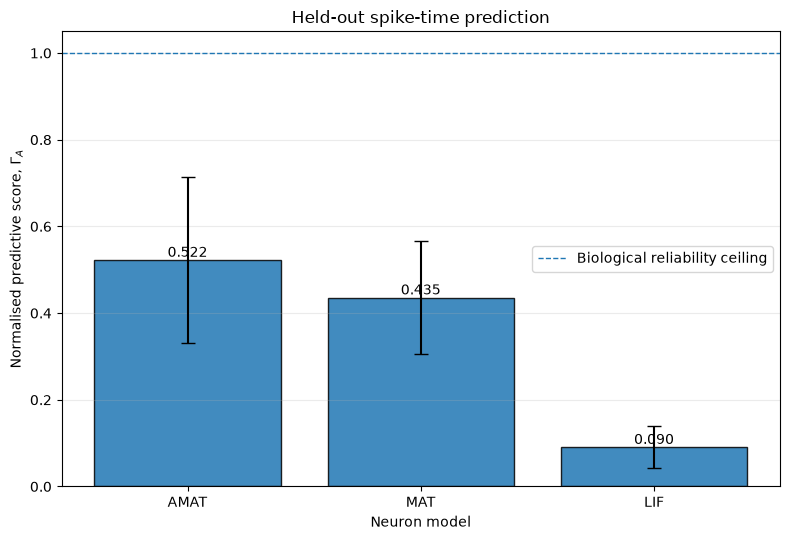

In [32]:
plot_table = results_table.copy()

labels = plot_table["model"].to_list()
scores = plot_table["gamma_A"].to_numpy()
score_errors = (
    plot_table["raw_gamma_sd_across_repetitions"].to_numpy()
    / R_VALIDATION
)

plt.figure(figsize=(8, 5.5))
bars = plt.bar(
    labels,
    scores,
    yerr=score_errors,
    capsize=5,
    edgecolor="black",
    alpha=0.85,
)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha="center",
        va="bottom",
    )

plt.axhline(1.0, linestyle="--", linewidth=1, label="Biological reliability ceiling")
plt.ylabel(r"Normalised predictive score, $\Gamma_A$")
plt.xlabel("Neuron model")
plt.title("Held-out spike-time prediction")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()